# Stage 3 · Step 03 — Strategy 2: classifier-guided targets with standard FM

Rather than differentiating the classification loss through the whole rollout, the frozen
classifier is used to *construct an explicit target* for each feature, and the flow is trained
toward it with an ordinary Flow Matching update. One step:

1. Roll $z$ through the **current** flow to get $\hat z$.
2. Push $\hat z$ through the frozen classifier and compute the classification loss.
3. Use $\partial\mathcal{L}/\partial\hat z$ to build a nearby improved representation
   $\hat z'$ — one or more gradient steps in feature space.
4. Treat $z$ as the source and $\hat z'$ as the target.
5. Perform a **standard FM** update between them:
   $t\sim\mathcal{U}(0,1)$, $z_t = (1-t)z + t\hat z'$, $u = \hat z' - z$,
   $\mathcal{L}_\mathrm{FM} = \mathrm{MSE}(v(z_t,t), u)$ — mean over the feature dimension, not on the same numeric scale as Stage 2's summed loss.
6. Recompute the targets as the flow changes during training.

**What differs from Stage 2's standard FM.** The update follows the same recipe —
same interpolation and velocity-matching structure — though the loss here averages over the
feature dimension as well as the batch (`nn.MSELoss`), unlike Stage 2's summed convention, so
the two are not on the same numeric scale. The difference that matters more is the target. Stage 2 aimed at **fixed class
prototypes**: one vector per class, known in advance, shared across every example of that
class. Here the target is **per-example and moves during training**, derived from the current
flow's own output. Stage 2's targets were a fixed point to converge to; these are recomputed
from the flow that is chasing them, so the objective is non-stationary by construction.

## 1 · Setup

In [1]:
from __future__ import annotations

import time

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn

from cvlab.data import make_kshot_subset
from cvlab.features import load_features
from cvlab.plotting import ArtifactWriter, apply_style
from cvlab3 import COMBOS, K_SHOT, SEEDS, T_STEPS, FrozenClassifier
from cvlab3.classifier import identity_flow
from cvlab3.guided import GuidedConfig, build_targets, train_classifier_guided
from cvlab3.paths import RESULTS_ROOT, step_dirs

apply_style()
PLOTS, TABLES = step_dirs("03_classifier_guided")
art = ArtifactWriter(PLOTS, TABLES)
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

setup = torch.load(RESULTS_ROOT / "frozen_classifiers.pt", map_location="cpu",
                   weights_only=False)
assert setup["verification"]["max_abs_delta_pp_vs_stage1"] == 0.0
strategy1 = pd.DataFrame(torch.load(RESULTS_ROOT / "strategy1_runs.pt", map_location="cpu",
                                    weights_only=False)["runs"])

FEATURES = {(e, d): {s: load_features(e, d, s) for s in ("train", "val", "test")}
            for e, d in COMBOS}
COMBO_LABEL = {("resnet18", "DTD"): "ResNet-18 / DTD",
               ("dinov2", "FGVC-Aircraft"): "DINOv2 / Aircraft",
               ("resnet18", "FGVC-Aircraft"): "ResNet-18 / Aircraft"}
ORDER = [COMBO_LABEL[c] for c in COMBOS]


def case(encoder, dataset, seed):
    # Everything one run needs: the frozen classifier and its exact Stage 1 data.
    key = f"{encoder}__{dataset}__K{K_SHOT}__seed{seed}"
    payload = setup["classifiers"][key]
    b = FEATURES[(encoder, dataset)]
    x, y = make_kshot_subset(b["train"].features, b["train"].labels, K_SHOT, seed)
    return key, payload, FrozenClassifier.from_state_dict(payload["state_dict"]).to(DEVICE), x, y, b


print(f"device = {DEVICE}   |   K = {K_SHOT}   |   T = {T_STEPS}   |   seeds = {SEEDS}")
print(f"Strategy 1 results loaded for comparison: {len(strategy1)} runs")

device = cuda   |   K = 10   |   T = 4   |   seeds = (0, 1, 2)
Strategy 1 results loaded for comparison: 81 runs


## 2 · What does the guidance actually produce?

Before training anything: the flow can never do better than the targets it is aimed at, so it
is worth measuring how good those targets are.

In [2]:
criterion = nn.CrossEntropyLoss()
rows = []
for encoder, dataset in COMBOS:
    key, payload, clf, x, y, b = case(encoder, dataset, 0)
    xg, yg = x.to(DEVICE), y.to(DEVICE)
    net = identity_flow(payload["dim"], seed=0, device=DEVICE)

    with torch.no_grad():
        base_logits = clf(xg)
        base_acc = (base_logits.argmax(1) == yg).float().mean().item()
        base_ce = criterion(base_logits, yg).item()

    # The raw gradient norm, which is what an *unnormalised* step size would be scaled by.
    xr = xg.clone().requires_grad_(True)
    g, = torch.autograd.grad(criterion(clf(xr), yg), xr)

    for eta in (0.5, 1.0, 2.0, 4.0):
        tgt, acc, ce = build_targets(net, clf, xg, yg, GuidedConfig(eta=eta), T_STEPS)
        rows.append({
            "encoder": encoder, "dataset": dataset, "eta": eta,
            "base_acc": base_acc, "target_acc": acc,
            "base_ce": base_ce, "target_ce": ce,
            "moved": (tgt - xg).norm(dim=1).mean().item(),
            "moved_rel": ((tgt - xg).norm(dim=1).mean() / xg.norm(dim=1).mean()).item(),
            "raw_grad_norm": g.norm(dim=1).mean().item(),
        })

targets_df = pd.DataFrame(rows)
art.table(targets_df, "target_quality")

print("Guided targets at identity (1 normalised step):\n")
for (e, d), grp in targets_df.groupby(["encoder", "dataset"], sort=False):
    r0 = grp.iloc[0]
    print(f"  {e:>9} / {d:<14}  base {r0['base_acc']*100:6.2f}% acc, CE {r0['base_ce']:.4f}")
    for _, r in grp.iterrows():
        print(f"      eta={r['eta']:<4} -> acc {r['target_acc']*100:6.2f}%  "
              f"CE {r['target_ce']:.4f}  (moved {r['moved_rel']*100:4.1f}% of ||z||)")
targets_df

  saved table -> tables/target_quality.csv  (12 rows)
Guided targets at identity (1 normalised step):

   resnet18 / DTD             base  96.38% acc, CE 0.5942
      eta=0.5  -> acc  98.51%  CE 0.4378  (moved  2.1% of ||z||)
      eta=1.0  -> acc  99.15%  CE 0.3159  (moved  4.2% of ||z||)
      eta=2.0  -> acc 100.00%  CE 0.1560  (moved  8.5% of ||z||)
      eta=4.0  -> acc 100.00%  CE 0.0328  (moved 16.9% of ||z||)
     dinov2 / FGVC-Aircraft   base 100.00% acc, CE 0.0045
      eta=0.5  -> acc 100.00%  CE 0.0021  (moved  1.0% of ||z||)
      eta=1.0  -> acc 100.00%  CE 0.0010  (moved  2.0% of ||z||)
      eta=2.0  -> acc 100.00%  CE 0.0002  (moved  4.0% of ||z||)
      eta=4.0  -> acc 100.00%  CE 0.0000  (moved  8.1% of ||z||)
   resnet18 / FGVC-Aircraft   base 100.00% acc, CE 0.0222
      eta=0.5  -> acc 100.00%  CE 0.0042  (moved  1.7% of ||z||)
      eta=1.0  -> acc 100.00%  CE 0.0008  (moved  3.5% of ||z||)
      eta=2.0  -> acc 100.00%  CE 0.0000  (moved  6.9% of ||z||)
      et

,encoder,dataset,eta,base_acc,target_acc,base_ce,target_ce,moved,moved_rel,raw_grad_norm
0,resnet18,DTD,0.5,0.96383,0.985106,0.594195,4.377762e-01,0.5,0.021175,0.000745
1,resnet18,DTD,1.0,0.96383,0.991489,0.594195,3.159387e-01,1.0,0.042350,0.000745
2,resnet18,DTD,2.0,0.96383,1.000000,0.594195,1.559699e-01,2.0,0.084701,0.000745
3,resnet18,DTD,4.0,0.96383,1.000000,0.594195,3.278555e-02,4.0,0.169402,0.000745
4,dinov2,FGVC-Aircraft,0.5,1.00000,1.000000,0.004541,2.098789e-03,0.5,0.010067,0.000007
5,dinov2,FGVC-Aircraft,1.0,1.00000,1.000000,0.004541,9.844751e-04,1.0,0.020133,0.000007
6,dinov2,FGVC-Aircraft,2.0,1.00000,1.000000,0.004541,2.271110e-04,2.0,0.040267,0.000007
7,dinov2,FGVC-Aircraft,4.0,1.00000,1.000000,0.004541,1.469931e-05,4.0,0.080534,0.000007
8,resnet18,FGVC-Aircraft,0.5,1.00000,1.000000,0.022229,4.150834e-03,0.5,0.017279,0.000075
9,resnet18,FGVC-Aircraft,1.0,1.00000,1.000000,0.022229,8.173676e-04,1.0,0.034558,0.000075


**On two of the three combinations the targets start at 100% accuracy and stay there** — the
probe already classifies its own training set perfectly (step 02), so there is no
*correctness* left for the guidance to add. What the gradient still does is push features into
**higher-confidence** regions: the target cross-entropy collapses toward zero.

So Strategy 2 on these combinations is not "move features so the classifier gets them right".
It is "move features so the classifier is *more certain* about answers it already gives" — a
margin-increasing transform. Whether that generalises is exactly what the sweep measures.

**Why the guidance step is normalised.** The raw gradient norm differs by two orders of
magnitude across combinations:

In [3]:
gn = targets_df.groupby(["encoder", "dataset"], sort=False)["raw_grad_norm"].first()
print("Mean raw |dL/dz| at identity:\n")
for (e, d), v in gn.items():
    print(f"  {e:>9} / {d:<14}  {v:.3e}   "
          f"(an unnormalised eta of 1000 would move it {v*1000:6.3f} units)")
print("\nUnder one nominal unnormalised step size the three combinations would be running")
print("effective steps ~100x apart. Normalising makes `eta` the distance actually travelled,")
print("directly comparable to ||z|| ~ 24-50. Section 4 tests the unnormalised variant anyway.")

Mean raw |dL/dz| at identity:

   resnet18 / DTD             7.449e-04   (an unnormalised eta of 1000 would move it  0.745 units)
     dinov2 / FGVC-Aircraft   7.071e-06   (an unnormalised eta of 1000 would move it  0.007 units)
   resnet18 / FGVC-Aircraft   7.528e-05   (an unnormalised eta of 1000 would move it  0.075 units)

Under one nominal unnormalised step size the three combinations would be running
effective steps ~100x apart. Normalising makes `eta` the distance actually travelled,
directly comparable to ||z|| ~ 24-50. Section 4 tests the unnormalised variant anyway.


## 3 · The main configuration

Learning rate $10^{-4}$ rather than $10^{-3}$: step 02 measured the project's default to be
actively harmful in this setting, costing roughly a full point. That lesson is carried in
rather than re-learned, and section 4 confirms it transfers.

In [4]:
def run_grid(config: GuidedConfig, tag: str, verbose: bool = True):
    # Train one configuration over every (combination, seed) and return tidy rows.
    out, curves = [], {}
    for encoder, dataset in COMBOS:
        for seed in SEEDS:
            key, payload, clf, x, y, b = case(encoder, dataset, seed)
            r = train_classifier_guided(
                payload["dim"], clf, x, y, b["val"].features, b["val"].labels,
                b["test"].features, b["test"].labels, seed=seed,
                baseline_acc=payload["stage1_test_acc"], T=T_STEPS,
                config=config, device=DEVICE,
            )
            out.append({
                "config": tag, "encoder": encoder, "dataset": dataset, "seed": seed,
                "lr": config.lr, "eta": config.eta,
                "n_target_steps": config.n_target_steps,
                "refresh_every": config.refresh_every,
                "normalize_step": config.normalize_step,
                "baseline_acc": r.baseline_acc, "test_acc": r.test_acc,
                "delta_pp": r.delta_pp, "best_val_acc": r.best_val_acc,
                "best_epoch": r.best_epoch,
                "target_train_acc": r.target_train_acc,
                "target_train_ce": r.target_train_ce,
                "relative_displacement": r.relative_displacement,
                "elapsed_s": r.elapsed_s,
            })
            curves[f"{tag}__{key}"] = r.history
    if verbose:
        df = pd.DataFrame(out)
        print(f"  {tag:<22} mean delta = {df['delta_pp'].mean():+6.2f} pp   "
              f"median epoch = {df['best_epoch'].median():5.0f}   "
              f"({df['elapsed_s'].sum():.0f}s)")
    return out, curves


MAIN = GuidedConfig()
all_rows, all_curves = [], {}
t0 = time.perf_counter()
print("Main configuration (eta=1.0, 1 step, refresh every epoch, normalised, lr=1e-4):")
rows, curves = run_grid(MAIN, "main")
all_rows += rows
all_curves.update(curves)
main_df = pd.DataFrame(rows)
main_df[["encoder", "dataset", "seed", "baseline_acc", "test_acc", "delta_pp", "best_epoch"]]

Main configuration (eta=1.0, 1 step, refresh every epoch, normalised, lr=1e-4):


  main                   mean delta =  +1.40 pp   median epoch =   135   (85s)


,encoder,dataset,seed,baseline_acc,test_acc,delta_pp,best_epoch
0,resnet18,DTD,0,0.511702,0.513298,0.159574,152
1,resnet18,DTD,1,0.515957,0.530851,1.489365,47
2,resnet18,DTD,2,0.533511,0.547872,1.436168,53
3,dinov2,FGVC-Aircraft,0,0.531953,0.537954,0.600064,125
4,dinov2,FGVC-Aircraft,1,0.516052,0.534953,1.890188,147
5,dinov2,FGVC-Aircraft,2,0.498050,0.512451,1.440144,83
6,resnet18,FGVC-Aircraft,0,0.267027,0.296730,2.970296,135
7,resnet18,FGVC-Aircraft,1,0.293129,0.303630,1.050106,191
8,resnet18,FGVC-Aircraft,2,0.276028,0.291329,1.530153,135


In [5]:
main_summary = (main_df.groupby(["encoder", "dataset"], sort=False)
                       .agg(baseline=("baseline_acc", "mean"),
                            strategy2=("test_acc", "mean"),
                            delta_pp=("delta_pp", "mean"),
                            delta_std=("delta_pp", lambda s: s.std(ddof=1)),
                            best_epoch=("best_epoch", "mean"),
                            rel_disp=("relative_displacement", "mean"))
                       .reset_index())
main_summary[["baseline", "strategy2"]] *= 100
art.table(main_summary, "strategy2_main_summary")

print("Strategy 2, main configuration, against the frozen linear probe:\n")
for _, r in main_summary.iterrows():
    print(f"  {r['encoder']:>9} / {r['dataset']:<14}  "
          f"{r['baseline']:6.2f}%  ->  {r['strategy2']:6.2f}%   "
          f"delta {r['delta_pp']:+6.2f} +/- {r['delta_std']:.2f} pp   "
          f"(epoch {r['best_epoch']:5.1f}, moved {r['rel_disp']*100:.1f}% of ||z||)")
main_summary

  saved table -> tables/strategy2_main_summary.csv  (3 rows)
Strategy 2, main configuration, against the frozen linear probe:

   resnet18 / DTD              52.04%  ->   53.07%   delta  +1.03 +/- 0.75 pp   (epoch  84.0, moved 22.7% of ||z||)
     dinov2 / FGVC-Aircraft    51.54%  ->   52.85%   delta  +1.31 +/- 0.65 pp   (epoch 118.3, moved 16.2% of ||z||)
   resnet18 / FGVC-Aircraft    27.87%  ->   29.72%   delta  +1.85 +/- 1.00 pp   (epoch 153.7, moved 12.2% of ||z||)


,encoder,dataset,baseline,strategy2,delta_pp,delta_std,best_epoch,rel_disp
0,resnet18,DTD,52.039005,53.067374,1.028369,0.752869,84.000000,0.227450
1,dinov2,FGVC-Aircraft,51.535151,52.845283,1.310132,0.654815,118.333333,0.162328
2,resnet18,FGVC-Aircraft,27.872786,29.722971,1.850185,0.999299,153.666667,0.121989


## 4 · The sweep

Strategy 2 exposes four knobs to experiment with: the feature-space step size, the number of
target-improvement steps, how often targets are recomputed, and whether the target updates
are normalized or otherwise constrained. Each is varied around the main configuration,
one factor at a time.

In [6]:
print("Feature-space step size (eta):")
for eta in (0.5, 2.0, 4.0):
    r, c = run_grid(GuidedConfig(eta=eta), f"eta={eta:g}")
    all_rows += r; all_curves.update(c)

print("\nNumber of target-improvement steps:")
for m in (3,):
    r, c = run_grid(GuidedConfig(n_target_steps=m), f"steps={m}")
    all_rows += r; all_curves.update(c)

print("\nHow often targets are recomputed:")
for k in (10, 50):
    r, c = run_grid(GuidedConfig(refresh_every=k), f"refresh={k}")
    all_rows += r; all_curves.update(c)

print("\nUnnormalised target updates:")
for eta in (1e3, 1e4):
    r, c = run_grid(GuidedConfig(eta=eta, normalize_step=False), f"raw_eta={eta:g}")
    all_rows += r; all_curves.update(c)

print("\nLearning rate (does step 02's lesson transfer?):")
for lr in (1e-3, 1e-5):
    r, c = run_grid(GuidedConfig(lr=lr), f"lr={lr:g}")
    all_rows += r; all_curves.update(c)

runs = pd.DataFrame(all_rows)
art.table(runs, "strategy2_all_runs")
print(f"\n{len(runs)} runs, {runs['elapsed_s'].sum()/60:.1f} minutes of training")

Feature-space step size (eta):


  eta=0.5                mean delta =  +1.53 pp   median epoch =   109   (85s)


  eta=2                  mean delta =  +1.54 pp   median epoch =   101   (87s)


  eta=4                  mean delta =  +1.18 pp   median epoch =   110   (2173s)

Number of target-improvement steps:


  steps=3                mean delta =  +1.12 pp   median epoch =    73   (87s)

How often targets are recomputed:


...

  refresh=50             mean delta =  +1.59 pp   median epoch =   164   (79s)

Unnormalised target updates:


  raw_eta=1000           mean delta =  +0.16 pp   median epoch =    87   (84s)


  raw_eta=10000          mean delta =  +0.46 pp   median epoch =   158   (85s)

Learning rate (does step 02's lesson transfer?):


  lr=0.001               mean delta =  +0.94 pp   median epoch =    13   (88s)


  lr=1e-05               mean delta =  +0.89 pp   median epoch =   177   (89s)
  saved table -> tables/strategy2_all_runs.csv  (99 rows)

99 runs, 50.3 minutes of training


In [7]:
cfg_summary = (runs.groupby("config", sort=False)
                   .agg(delta_pp=("delta_pp", "mean"),
                        delta_std=("delta_pp", lambda s: s.std(ddof=1)),
                        best_epoch=("best_epoch", "mean"),
                        rel_disp=("relative_displacement", "mean"),
                        n=("delta_pp", "size"))
                   .reset_index())
art.table(cfg_summary, "strategy2_config_summary")

print("Every configuration, averaged over 3 combinations x 3 seeds:\n")
print(f"  {'config':<14} {'delta (pp)':>16}  {'sel. epoch':>10}  {'moved':>8}")
print("  " + "-" * 54)
for _, r in cfg_summary.iterrows():
    print(f"  {r['config']:<14} {r['delta_pp']:+7.2f} +/- {r['delta_std']:5.2f}  "
          f"{r['best_epoch']:10.1f}  {r['rel_disp']*100:7.1f}%")
cfg_summary

  saved table -> tables/strategy2_config_summary.csv  (11 rows)
Every configuration, averaged over 3 combinations x 3 seeds:

  config               delta (pp)  sel. epoch     moved
  ------------------------------------------------------
  main             +1.40 +/-  0.79       118.7     17.1%
  eta=0.5          +1.53 +/-  0.66       109.4     12.0%
  eta=2            +1.54 +/-  0.72        90.9     19.5%
  eta=4            +1.18 +/-  0.83       103.0     34.0%
  steps=3          +1.12 +/-  0.84        83.4     29.7%
  refresh=10       +1.82 +/-  0.80       116.2     11.3%
  refresh=50       +1.59 +/-  0.76       142.9      6.1%
  raw_eta=1000     +0.16 +/-  0.24        99.2      2.1%
  raw_eta=10000    +0.46 +/-  0.46       132.8      4.3%
  lr=0.001         +0.94 +/-  0.71        17.3     10.8%
  lr=1e-05         +0.89 +/-  0.80       143.6      8.4%


,config,delta_pp,delta_std,best_epoch,rel_disp,n
0,main,1.396229,0.793317,118.666667,0.170589,9
1,eta=0.5,1.533519,0.659324,109.444444,0.120000,9
2,eta=2,1.537157,0.718748,90.888889,0.195013,9
3,eta=4,1.178015,0.827771,103.000000,0.340130,9
4,steps=3,1.124066,0.835858,83.444444,0.296819,9
5,refresh=10,1.815367,0.795422,116.222222,0.112687,9
6,refresh=50,1.590486,0.762062,142.888889,0.060899,9
7,raw_eta=1000,0.162898,0.241790,99.222222,0.021073,9
8,raw_eta=10000,0.462623,0.457004,132.777778,0.042915,9
9,lr=0.001,0.944364,0.711122,17.333333,0.107942,9


## 5 · Strategy 2 against Strategy 1

Both are selected by the same rule (best validation accuracy) against the same frozen
classifier, on the same subsets and seeds. One thing has to be controlled for before the
comparison means anything.

**Strategy 2's "main" configuration already uses lr $10^{-4}$**, because step 02 measured
$10^{-3}$ to be actively harmful and that lesson was carried in. Strategy 1's "main" was
$10^{-3}$. Comparing the two "main" configurations would therefore be comparing Strategy 2
*with* the benefit of step 02's finding against Strategy 1 *without* it — a difference in
tuning, not in objective.

The honest comparison holds the learning rate fixed and varies only the objective.

In [8]:
from scipy import stats

# Matched learning rate: Strategy 2's main config IS lr=1e-4, so Strategy 1's lr=1e-4 arm
# is its like-for-like counterpart.
s1_m = strategy1[strategy1["config"] == "lr=0.0001"]
s2_m = runs[runs["config"] == "main"]

comp = []
for encoder, dataset in COMBOS:
    a = s1_m[(s1_m.encoder == encoder) & (s1_m.dataset == dataset)]
    b_ = s2_m[(s2_m.encoder == encoder) & (s2_m.dataset == dataset)]
    comp.append({
        "encoder": encoder, "dataset": dataset,
        "baseline": a["baseline_acc"].mean() * 100,
        "strategy1": a["test_acc"].mean() * 100,
        "strategy1_delta": a["delta_pp"].mean(),
        "strategy1_std": a["delta_pp"].std(ddof=1),
        "strategy2": b_["test_acc"].mean() * 100,
        "strategy2_delta": b_["delta_pp"].mean(),
        "strategy2_std": b_["delta_pp"].std(ddof=1),
    })
comparison = pd.DataFrame(comp)
comparison["difference"] = comparison["strategy2_delta"] - comparison["strategy1_delta"]
art.table(comparison, "strategy_comparison_matched_lr")

print("Both strategies at lr = 1e-4, against the frozen probe:\n")
print(f"  {'combination':<26} {'probe':>8} {'strategy 1':>17} {'strategy 2':>17}   diff")
print("  " + "-" * 80)
for _, r in comparison.iterrows():
    print(f"  {r['encoder'] + '/' + r['dataset']:<26} {r['baseline']:7.2f}% "
          f"{r['strategy1']:8.2f}% ({r['strategy1_delta']:+5.2f}) "
          f"{r['strategy2']:8.2f}% ({r['strategy2_delta']:+5.2f})  {r['difference']:+6.2f}")

t, pval = stats.ttest_ind(s2_m["delta_pp"], s1_m["delta_pp"])
print(f"\n  overall: S1 {s1_m['delta_pp'].mean():+.2f} pp   "
      f"S2 {s2_m['delta_pp'].mean():+.2f} pp   "
      f"difference {s2_m['delta_pp'].mean() - s1_m['delta_pp'].mean():+.2f} pp   p = {pval:.3f}")
comparison

  saved table -> tables/strategy_comparison_matched_lr.csv  (3 rows)
Both strategies at lr = 1e-4, against the frozen probe:

  combination                   probe        strategy 1        strategy 2   diff
  --------------------------------------------------------------------------------
  resnet18/DTD                 52.04%    52.15% (+0.11)    53.07% (+1.03)   +0.92
  dinov2/FGVC-Aircraft         51.54%    54.13% (+2.59)    52.85% (+1.31)   -1.28
  resnet18/FGVC-Aircraft       27.87%    28.97% (+1.10)    29.72% (+1.85)   +0.75

  overall: S1 +1.27 pp   S2 +1.40 pp   difference +0.13 pp   p = 0.802


,encoder,dataset,baseline,strategy1,strategy1_delta,strategy1_std,strategy2,strategy2_delta,strategy2_std,difference
0,resnet18,DTD,52.039005,52.145390,0.106384,0.281465,53.067374,1.028369,0.752869,0.921985
1,dinov2,FGVC-Aircraft,51.535151,54.125410,2.590259,1.060907,52.845283,1.310132,0.654815,-1.280127
2,resnet18,FGVC-Aircraft,27.872786,28.972897,1.100111,1.029035,29.722971,1.850185,0.999299,0.750074


In [9]:
# The same comparison at every learning rate both strategies were run at.
pairs = [("main", "lr=0.001", "1e-3"), ("lr=0.0001", "main", "1e-4"),
         ("lr=1e-05", "lr=1e-05", "1e-5")]
rows = []
for s1c, s2c, label in pairs:
    a = strategy1[strategy1["config"] == s1c]["delta_pp"]
    b_ = runs[runs["config"] == s2c]["delta_pp"]
    rows.append({"learning_rate": label, "strategy1": a.mean(), "strategy2": b_.mean(),
                 "difference": b_.mean() - a.mean()})
matched = pd.DataFrame(rows)
art.table(matched, "matched_learning_rate_comparison")

print("Same objective comparison, at each learning rate:\n")
print(f"  {'lr':<8} {'strategy 1':>12} {'strategy 2':>12} {'difference':>12}")
print("  " + "-" * 48)
for _, r in matched.iterrows():
    print(f"  {r['learning_rate']:<8} {r['strategy1']:+11.2f} {r['strategy2']:+11.2f} "
          f"{r['difference']:+11.2f}")
matched

  saved table -> tables/matched_learning_rate_comparison.csv  (3 rows)
Same objective comparison, at each learning rate:

  lr         strategy 1   strategy 2   difference
  ------------------------------------------------
  1e-3           +0.15       +0.94       +0.79
  1e-4           +1.27       +1.40       +0.13
  1e-5           +1.21       +0.89       -0.31


,learning_rate,strategy1,strategy2,difference
0,1e-3,0.151972,0.944364,0.792392
1,1e-4,1.265585,1.396229,0.130644
2,1e-5,1.206492,0.893896,-0.312597


### What the comparison shows

**At matched learning rate the two strategies are indistinguishable.** At $10^{-4}$ the gap is
$+0.13$ pp with $p = 0.80$; at $10^{-5}$ Strategy 1 is slightly ahead. Per combination they
trade wins — Strategy 2 is better on DTD and ResNet-18/Aircraft, Strategy 1 is clearly better
on DINOv2/Aircraft. Even best-configuration against best-configuration (both selected after
the fact, so the comparison flatters both) the gap is $+0.55$ pp at $p = 0.30$.

So the answer — does classifier-guided training beat end-to-end
rolled-out training — is **no, not on peak accuracy**.

**Where Strategy 2 is genuinely better is robustness.** At $10^{-3}$, Strategy 1 collapses to
$+0.15$ pp while Strategy 2 holds $+0.94$ pp. There is a mechanism for that: Strategy 1
optimises the classification loss directly, so a large step size lets it memorise the training
labels within a handful of epochs. Strategy 2 optimises an **MSE regression onto a target
vector**; the labels only enter through where that target was placed, so the same step size
cannot memorise them nearly as fast. Every one of Strategy 2's 11 configurations is positive,
and 91 of its 99 runs improve on the probe, against 83% for Strategy 1.

Two findings from the sweep itself:

**Refreshing the targets *less* often is better.** Strategy 2 recomputes its targets
as the flow changes; recomputing every epoch gives $+1.40$ pp, every 10 epochs $+1.82$ pp,
every 50 epochs $+1.59$ pp. Recomputing constantly means chasing a target that moves with the
flow that is chasing it — letting it go stale for a few epochs makes the objective closer to
stationary, and it trains better.

**Normalising the guidance step matters more than any other choice.** Unnormalised updates give
$+0.16$ and $+0.46$ pp against $+1.4$ to $+1.8$ for normalised ones — because, as section 2
measured, the raw gradient norm differs 100x across combinations, so a single nominal step size
means three very different effective steps.

## 6 · Training and validation curves

Representative curves for both Stage 3 methods; these are Strategy 2's.
The extra line is the **target accuracy** — the ceiling the flow is aimed at, which moves
during training because the targets are recomputed from the flow itself.

  saved plot  -> plots/training_curves.png


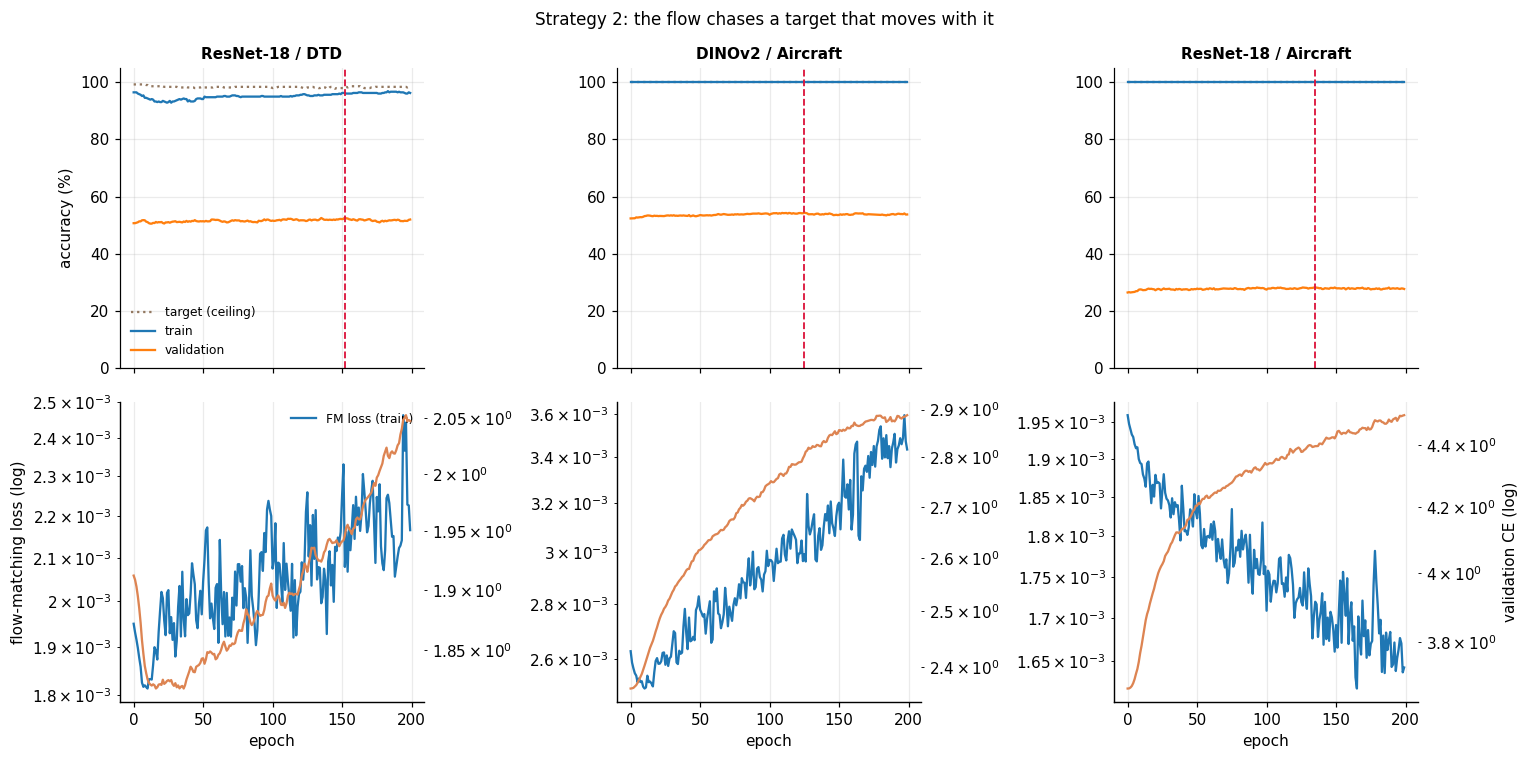

In [10]:
fig, axes = plt.subplots(2, 3, figsize=(14, 7), sharex=True)
for col, (encoder, dataset) in enumerate(COMBOS):
    h = all_curves[f"main__{encoder}__{dataset}__K{K_SHOT}__seed0"]
    ep = np.arange(len(h["train_acc"]))
    sel = int(main_df[(main_df.encoder == encoder) & (main_df.dataset == dataset)
                      & (main_df.seed == 0)]["best_epoch"].iloc[0])

    ax = axes[0, col]
    ax.plot(ep, np.array(h["target_acc"]) * 100, color="#937860", ls=":", label="target (ceiling)")
    ax.plot(ep, np.array(h["train_acc"]) * 100, label="train")
    ax.plot(ep, np.array(h["val_acc"]) * 100, label="validation")
    ax.axvline(sel, color="crimson", ls="--", lw=1.2)
    ax.set_title(COMBO_LABEL[(encoder, dataset)], fontsize=10)
    ax.set_ylabel("accuracy (%)" if col == 0 else "")
    ax.set_ylim(0, 105)
    if col == 0:
        ax.legend(fontsize=8)

    ax = axes[1, col]
    ax.plot(ep, h["train_loss"], label="FM loss (train)")
    ax.set_yscale("log")
    ax.set_xlabel("epoch")
    ax.set_ylabel("flow-matching loss (log)" if col == 0 else "")
    ax2 = ax.twinx()
    ax2.plot(ep, h["val_loss"], color="#DD8452", label="classifier CE (val)")
    ax2.set_yscale("log")
    ax2.grid(False)
    if col == 2:
        ax2.set_ylabel("validation CE (log)")
    if col == 0:
        ax.legend(fontsize=8, loc="upper right")

fig.suptitle("Strategy 2: the flow chases a target that moves with it", fontsize=11)
fig.tight_layout()
art.figure(fig, "training_curves")
plt.show()

  saved plot  -> plots/strategy2_results.png


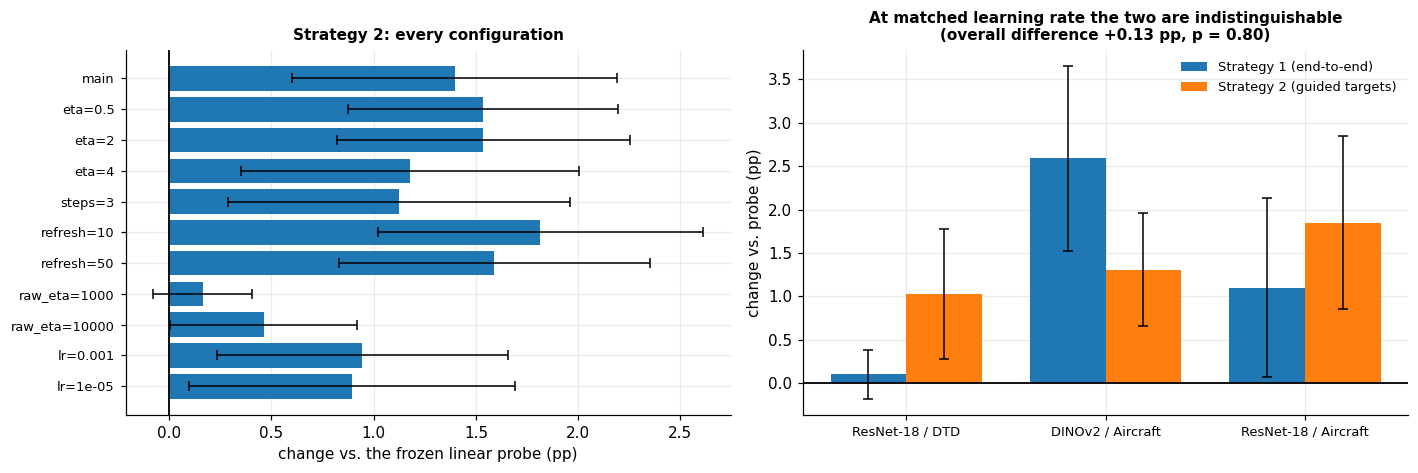

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.4))

ax = axes[0]
cs = cfg_summary
ys = np.arange(len(cs))
ax.barh(ys, cs["delta_pp"], xerr=cs["delta_std"], error_kw=dict(lw=1, capsize=3))
ax.axvline(0, color="black", lw=1.2)
ax.set_yticks(ys); ax.set_yticklabels(cs["config"], fontsize=8.5)
ax.invert_yaxis()
ax.set_xlabel("change vs. the frozen linear probe (pp)")
ax.set_title("Strategy 2: every configuration", fontsize=10)

ax = axes[1]
xs = np.arange(len(ORDER))
ax.bar(xs - 0.19, comparison["strategy1_delta"], 0.38,
       yerr=comparison["strategy1_std"], error_kw=dict(lw=1, capsize=3),
       label="Strategy 1 (end-to-end)")
ax.bar(xs + 0.19, comparison["strategy2_delta"], 0.38,
       yerr=comparison["strategy2_std"], error_kw=dict(lw=1, capsize=3),
       label="Strategy 2 (guided targets)")
ax.axhline(0, color="black", lw=1.2)
ax.set_xticks(xs); ax.set_xticklabels(ORDER, fontsize=8.5)
ax.set_ylabel("change vs. probe (pp)")
ax.set_title("At matched learning rate the two are indistinguishable\n"
             "(overall difference +0.13 pp, p = 0.80)", fontsize=10)
ax.legend(fontsize=8.5)

fig.tight_layout()
art.figure(fig, "strategy2_results")
plt.show()

## 7 · Saving

In [12]:
torch.save({"runs": runs.to_dict("records"), "curves": all_curves,
            "config_main": MAIN.as_dict(),
            "targets": targets_df.to_dict("records")},
           RESULTS_ROOT / "strategy2_runs.pt")
print(f"saved -> {RESULTS_ROOT / 'strategy2_runs.pt'} "
      f"({(RESULTS_ROOT / 'strategy2_runs.pt').stat().st_size/1024:.0f} KB)")
art.manifest()

saved -> C:\Users\<user>\Project in Computer Vision\ProjectInComputerVision\Stage_3\results\strategy2_runs.pt (1073 KB)
8 artefacts in C:\Users\<user>\Project in Computer Vision\ProjectInComputerVision\Stage_3\Work\03_classifier_guided


,kind,file,size_KB
0,plot,plots/strategy2_results.png,75.1
1,plot,plots/training_curves.png,229.3
2,table,tables/matched_learning_rate_comparison.csv,0.2
3,table,tables/strategy2_all_runs.csv,19.6
4,table,tables/strategy2_config_summary.csv,1.0
5,table,tables/strategy2_main_summary.csv,0.5
6,table,tables/strategy_comparison_matched_lr.csv,0.6
7,table,tables/target_quality.csv,1.7


In [13]:
best_cfg = cfg_summary.loc[cfg_summary["delta_pp"].idxmax(), "config"]
print("Step 03 complete.\n")
print(f"  {len(runs)} runs across {runs['config'].nunique()} configurations "
      f"({runs['elapsed_s'].sum()/60:.1f} min of training)")
print(f"  main configuration      : {main_df['delta_pp'].mean():+.2f} pp")
print(f"  best configuration      : {best_cfg} ({cfg_summary['delta_pp'].max():+.2f} pp)")
print(f"  runs improving on probe : {(runs['delta_pp'] > 0).sum()}/{len(runs)} "
      f"({(runs['delta_pp'] > 0).mean()*100:.0f}%), all 11 configurations positive")
print(f"  vs Strategy 1 at lr=1e-4: {s2_m['delta_pp'].mean() - s1_m['delta_pp'].mean():+.2f} pp "
      f"(p = {pval:.2f}) - indistinguishable on peak accuracy")
print(f"  vs Strategy 1 at lr=1e-3: "
      f"{runs[runs['config']=='lr=0.001']['delta_pp'].mean():+.2f} pp vs "
      f"{strategy1[strategy1['config']=='main']['delta_pp'].mean():+.2f} pp "
      f"- Strategy 2 is far more robust")
print("\nNext: step 04 consolidates both strategies into the required comparison.")

Step 03 complete.

  99 runs across 11 configurations (50.3 min of training)
  main configuration      : +1.40 pp
  best configuration      : refresh=10 (+1.82 pp)
  runs improving on probe : 91/99 (92%), all 11 configurations positive
  vs Strategy 1 at lr=1e-4: +0.13 pp (p = 0.80) - indistinguishable on peak accuracy
  vs Strategy 1 at lr=1e-3: +0.94 pp vs +0.15 pp - Strategy 2 is far more robust

Next: step 04 consolidates both strategies into the required comparison.
